<a href="https://colab.research.google.com/github/francescopatane96/eNERVE/blob/main/5_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#5 Models

In [ ]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.model_selection import RandomizedSearchCV
import tqdm
from tqdm.notebook import tqdm
from sklearn.model_selection import RepeatedStratifiedKFold
from scipy.stats import loguniform

In [ ]:
df = pd.read_csv('full_matrix.csv', header=0, sep=',')
df

In [ ]:
df = df.drop('Subcellular location ', axis=1)


In [ ]:
print(df[['in', 'membrane', 'out']].value_counts())  #check for dataset balance among classes

in  membrane  out
0   0         1      336
    1         0      336
1   0         0      336
dtype: int64


In [ ]:
df = df.drop(df.columns[0], axis=1)


In [ ]:
df

In [ ]:
X = df.iloc[: , :-3]


In [ ]:
y=df[['in', 'membrane', 'out']]

In [ ]:
X

In [ ]:
y

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                   random_state=42, 
                                   test_size=0.20, 
                                   shuffle=True)

1. RandomForestClassifier

In [ ]:
grid = {'bootstrap': True,   #grid search da usare dopo random search
 'criterion': 'mse',
 'max_depth': None,
 'max_features': 'auto',
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_impurity_split': None,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 10,
 'n_jobs': 1,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

In [ ]:
grid = {'n_estimators': np.arange(1000, 5000, step = 200),
        'min_samples_leaf': np.arange(4),
        'max_depth': list(np.arange(10, 50, step=5)), #+ [None],
        'min_samples_split': np.arange(10, 80, 5),
        'criterion': ['entropy'],
        'max_features': [0.5]#, 1, 'log2', 'auto', None],      #auto=sqrt
        #'max_samples': [500]
        }
        

In [ ]:
rs_model = RandomizedSearchCV(RandomForestClassifier(n_jobs=-1, random_state=42),     #n_jobs = n. cores (-1=all processors)
                              param_distributions=grid,
                              n_iter=100,                         #The number of parameter settings that are tried is given by n_iter.
                              cv=2,                              #number of cross-validation folds
                              verbose=3,
                              return_train_score=True,
                              scoring='accuracy',
                              random_state=42,
                              
                              )

In [ ]:
model = RandomForestClassifier(n_jobs=-1, random_state=42)

In [ ]:
model.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [ ]:
rs_model.get_params().keys()

In [ ]:
rs_model.get_params().values()

dict_values([2, nan, True, 0.0, None, 'gini', None, 'auto', None, None, 0.0, 1, 2, 0.0, 100, -1, False, 42, 0, False, RandomForestClassifier(n_jobs=-1, random_state=42), 100, None, {'n_estimators': array([1000, 1200, 1400, 1600, 1800, 2000, 2200, 2400, 2600, 2800, 3000,
       3200, 3400, 3600, 3800, 4000, 4200, 4400, 4600, 4800]), 'min_samples_leaf': array([0, 1, 2, 3]), 'max_depth': [10, 15, 20, 25, 30, 35, 40, 45], 'min_samples_split': array([10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75]), 'criterion': ['entropy'], 'max_features': [0.5]}, '2*n_jobs', 42, True, True, 'accuracy', 1])

In [ ]:
rs_model.fit(X_train, y_train)

Fitting 2 folds for each of 100 candidates, totalling 200 fits


KeyboardInterrupt: ignored

In [ ]:
pred = rs_model.predict(X_test)
pred

array([[0, 0, 1],
       [0, 0, 0],
       [0, 0, 1],
       [0, 1, 0],
       [0, 0, 0],
       [1, 0, 0],
       [0, 0, 0],
       [0, 0, 0],
       [1, 0, 0],
       [0, 1, 0],
       [0, 0, 1],
       [0, 1, 0],
       [0, 0, 1],
       [0, 1, 0],
       [1, 0, 0],
       [1, 0, 0],
       [0, 0, 1],
       [0, 0, 1],
       [0, 0, 0],
       [1, 0, 0],
       [0, 0, 1],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [0, 0, 0],
       [0, 0, 0],
       [0, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [0, 0, 1],
       [0, 0, 1],
       [0, 0, 1],
       [0, 0, 1],
       [1, 0, 0],
       [0, 0, 1],
       [1, 0, 0],
       [0, 0, 1],
       [1, 0, 0],
       [1, 0, 0],
       [0, 0, 0],
       [1, 0, 0],
       [0, 0, 0],
       [0, 1, 0],
       [0, 0, 1],
       [0, 0, 0],
       [0, 0, 0],
       [0, 1, 0],
       [0, 0, 1],
       [0, 0, 1],
       [0, 0, 1],
       [0, 1, 0],
       [0, 0, 1],
       [0, 0, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0,

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
y_test

In [ ]:
rs_model.predict_proba(X_test)

In [ ]:
#importances = model.feature_importances_

In [ ]:
#final_df = pd.DataFrame({'features': pd.DataFrame(X).columns, 'importances':importances})
#final_df.set_index('importances')

In [ ]:
#final_df.plot.bar(color='teal')

In [ ]:
#final_df

In [ ]:
rs_model.score(X_train, y_train)   #training score

0.9838709677419355

In [ ]:
model.score(X_train, y_train)

1.0

In [ ]:
rs_model.score(X_test, y_test)   #test score

0.5693069306930693

In [ ]:
model.score(X_test, y_test)

0.5

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.71      0.43      0.54        70
           1       0.78      0.41      0.53        69
           2       0.80      0.68      0.74        63

   micro avg       0.77      0.50      0.60       202
   macro avg       0.76      0.51      0.60       202
weighted avg       0.76      0.50      0.60       202
 samples avg       0.50      0.50      0.50       202



/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.69      0.51      0.59        70
           1       0.78      0.41      0.53        69
           2       0.81      0.81      0.81        63

   micro avg       0.76      0.57      0.65       202
   macro avg       0.76      0.58      0.64       202
weighted avg       0.76      0.57      0.64       202
 samples avg       0.57      0.57      0.57       202



/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
rs_model.best_params_

{'n_estimators': 1300,
 'min_samples_split': 11,
 'min_samples_leaf': 4,
 'max_features': 0.5,
 'max_depth': None,
 'criterion': 'entropy'}

In [ ]:

rs_model.best_score_

0.5359801488833746

In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
cm = confusion_matrix(y_test.values.argmax(axis=1), y_pred.argmax(axis=1)) #normalize='all')
cm_df = pd.DataFrame(cm,
                     index = ['in', 'membrane', 'out'],
                     columns = ['in', 'membrane', 'out'])

In [ ]:
confusion_matrix()

In [ ]:
#Plotting the confusion matrix
def plot_confusion_matrix():
  plt.figure(figsize=(10,8))
  colormap = sns.color_palette("icefire")
  sns.heatmap(cm_df, annot=True, cmap=colormap)
  plt.title('Confusion Matrix')
  plt.ylabel('True Values')
  plt.xlabel('Predicted Values')
  plt.show()

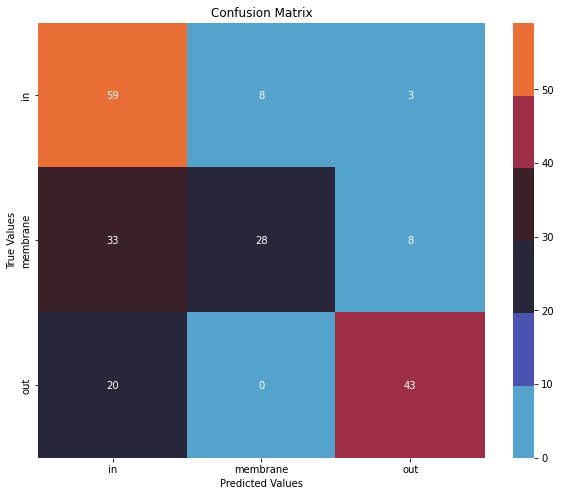

In [ ]:
confusion_matrix()

2. GradientBoostingClassifier

This algorithm builds an additive model in a forward stage-wise fashion; it allows for the optimization of arbitrary differentiable loss functions. In each stage n_classes_ regression trees are fit on the negative gradient of the loss function, e.g. binary or multiclass log loss.

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

In [ ]:
clf = GradientBoostingClassifier(n_estimators=1000, learning_rate=1.0, max_depth=1, random_state=42).fit(X_train, y_train.values.argmax(axis=1))

In [ ]:
y_pred = clf.predict(X_test)

In [ ]:
clf.score(X_train, y_train.values.argmax(axis=1))

1.0

In [ ]:
clf.score(X_test, y_test.values.argmax(axis=1))

0.6683168316831684

In [ ]:
cm = confusion_matrix(y_test, y_pred) 
cm_df = pd.DataFrame(cm,
                     index = ['in', 'membrane', 'out'],
                     columns = ['in', 'membrane', 'out'])

TypeError: ignored

In [ ]:
print(classification_report(y_test.values.argmax(axis=1), y_pred))

              precision    recall  f1-score   support

           0       0.64      0.69      0.66        70
           1       0.65      0.49      0.56        69
           2       0.71      0.84      0.77        63

    accuracy                           0.67       202
   macro avg       0.67      0.67      0.66       202
weighted avg       0.67      0.67      0.66       202



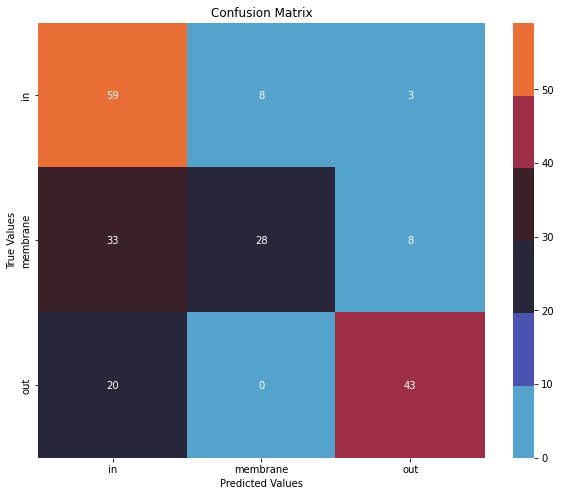

In [ ]:
confusion_matrix()

In [ ]:
from sklearn.metrics import RocCurveDisplay

In [ ]:
svc_disp = RocCurveDisplay.from_estimator(clf, X_test, y_test)
plt.show()

In [ ]:
ax = plt.gca()
rfc_disp = RocCurveDisplay.from_estimator(clf, X_test, y_test, ax=ax, alpha=0.8)
#svc_disp.plot(ax=ax, alpha=0.8) secondo modello
plt.show()

3. AdaBoostClassifier

An AdaBoost [1] classifier is a meta-estimator that begins by fitting a classifier on the original dataset and then fits additional copies of the classifier on the same dataset but where the weights of incorrectly classified instances are adjusted such that subsequent classifiers focus more on difficult cases.

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.datasets import make_classification

In [ ]:
X, y = make_classification(n_samples=1000, n_features=1232, n_informative=2, n_redundant=0,random_state=42, shuffle=True)

In [ ]:
clf = AdaBoostClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train.values.argmax(axis=1))

AdaBoostClassifier(n_estimators=100, random_state=42)

In [ ]:
y_pred = clf.predict(X_test)

In [ ]:
clf.score(X_train, y_train.values.argmax(axis=1))

0.8126550868486352

In [ ]:
clf.score(X_test, y_test.values.argmax(axis=1))

0.6485148514851485

In [ ]:
print(classification_report(y_test.values.argmax(axis=1), y_pred))

              precision    recall  f1-score   support

           0       0.61      0.67      0.64        70
           1       0.62      0.57      0.59        69
           2       0.73      0.71      0.72        63

    accuracy                           0.65       202
   macro avg       0.65      0.65      0.65       202
weighted avg       0.65      0.65      0.65       202



4. ExtraTreesClassifier

This class implements a meta estimator that fits a number of randomized decision trees (a.k.a. extra-trees) on various sub-samples of the dataset and uses averaging to improve the predictive accuracy and control over-fitting.


In [ ]:
from sklearn.ensemble import ExtraTreesClassifier

In [ ]:
X, y = make_classification(n_features=1232, random_state=42)

In [ ]:
 clf = ExtraTreesClassifier(n_estimators=1000, random_state=42)
 clf.fit(X_train, y_train)

ExtraTreesClassifier(n_estimators=1000, random_state=42)

In [ ]:
y_pred = clf.predict(X_test)

In [ ]:
clf.score(X_train, y_train)

1.0

In [ ]:
clf.score(X_test, y_test)

0.5

In [ ]:
print(classification_report(y_test.values.argmax(axis=1), y_pred.argmax(axis=1)))

5. BaggingClassifier

A Bagging classifier is an ensemble meta-estimator that fits base classifiers each on random subsets of the original dataset and then aggregate their individual predictions (either by voting or by averaging) to form a final prediction. Such a meta-estimator can typically be used as a way to reduce the variance of a black-box estimator (e.g., a decision tree), by introducing randomization into its construction procedure and then making an ensemble out of it.

This algorithm encompasses several works from the literature. When random subsets of the dataset are drawn as random subsets of the samples, then this algorithm is known as Pasting [1]. If samples are drawn with replacement, then the method is known as Bagging [2]. When random subsets of the dataset are drawn as random subsets of the features, then the method is known as Random Subspaces [3]. Finally, when base estimators are built on subsets of both samples and features, then the method is known as Random Patches [4].

In [ ]:
from sklearn.ensemble import BaggingClassifier
from sklearn.svm import SVC

In [ ]:
clf = BaggingClassifier(base_estimator=SVC(), n_estimators=100, random_state=42).fit(X_train, y_train.values.argmax(axis=1))

In [ ]:
y_pred = clf.predict(X_test)

In [ ]:
clf.score(X_train, y_train.values.argmax(axis=1))

0.5012406947890818

In [ ]:
clf.score(X_test, y_test.values.argmax(axis=1))

0.4752475247524752

In [ ]:
print(classification_report(y_test.values.argmax(axis=1), y_pred))

6. StackingClassifier

Stack of estimators with a final classifier.

Stacked generalization consists in stacking the output of individual estimator and use a classifier to compute the final prediction. Stacking allows to use the strength of each individual estimator by using their output as input of a final estimator.

Note that estimators_ are fitted on the full X while final_estimator_ is trained using cross-validated predictions of the base estimators using cross_val_predict.



7. Logistic regression

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
clf = LogisticRegression(random_state=42, max_iter=10000000).fit(X_train, y_train.values.argmax(axis=1))

In [ ]:
y_pred = clf.predict(X_test)

In [ ]:
clf.score(X_train, y_train.values.argmax(axis=1))

1.0

In [ ]:
clf.score(X_test, y_test.values.argmax(axis=1))

0.5693069306930693

In [ ]:
print(classification_report(y_test.values.argmax(axis=1), y_pred))

SGDClassifier

In [ ]:
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

In [ ]:
clf = make_pipeline(StandardScaler(),SGDClassifier(max_iter=1000, tol=1e-3))

In [ ]:
clf.fit(X_train, y_train.values.argmax(axis=1))

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('sgdclassifier', SGDClassifier())])

In [ ]:
y_pred = clf.predict(X_test)

In [ ]:
clf.score(X_train, y_train.values.argmax(axis=1))

0.9987593052109182

In [ ]:
clf.score(X_test, y_test.values.argmax(axis=1))

0.5792079207920792

In [ ]:
print(classification_report(y_test.values.argmax(axis=1), y_pred))

              precision    recall  f1-score   support

           0       0.57      0.50      0.53        70
           1       0.52      0.43      0.47        69
           2       0.63      0.83      0.71        63

    accuracy                           0.58       202
   macro avg       0.57      0.59      0.57       202
weighted avg       0.57      0.58      0.57       202



RidgeClassifierCV

In [ ]:
from sklearn.linear_model import RidgeClassifierCV

In [ ]:
clf = RidgeClassifierCV(alphas=[1e-3, 1e-2, 1e-1, 1]).fit(X_train, y_train)

In [ ]:
y_pred = clf.predict(X_test)

In [ ]:
clf.score(X_train, y_train)

0.9652605459057072

In [ ]:
y_score = clf.score(X_test, y_test)

In [ ]:
print(classification_report(y_test.values.argmax(axis=1), y_pred.argmax(axis=1)))

              precision    recall  f1-score   support

           0       0.46      0.63      0.53        70
           1       0.54      0.43      0.48        69
           2       0.58      0.46      0.51        63

    accuracy                           0.51       202
   macro avg       0.52      0.51      0.51       202
weighted avg       0.52      0.51      0.51       202



In [ ]:
from sklearn.metrics import roc_auc_score

In [ ]:
roc_auc_score(y_test, y_score)

TypeError: ignored

OneVsOneClassifier

In [ ]:
from sklearn.multiclass import OneVsOneClassifier
from sklearn.svm import LinearSVC

In [ ]:
clf = OneVsOneClassifier(LinearSVC(random_state=42, max_iter=100000000)).fit(X_train, y_train.values.argmax(axis=1))

In [ ]:
y_pred = clf.predict(X_test)

In [ ]:
clf.score(X_train, y_train.values.argmax(axis=1))

1.0

In [ ]:
clf.score(X_test, y_test.values.argmax(axis=1))

0.5891089108910891

In [ ]:
print(classification_report(y_test.values.argmax(axis=1), y_pred))

              precision    recall  f1-score   support

           0       0.56      0.57      0.57        70
           1       0.56      0.46      0.51        69
           2       0.64      0.75      0.69        63

    accuracy                           0.59       202
   macro avg       0.59      0.59      0.59       202
weighted avg       0.59      0.59      0.58       202



NN

In [ ]:
from sklearn.neural_network import MLPClassifier

In [ ]:
clf = MLPClassifier(random_state=42, max_iter=1000).fit(X_train, y_train)

In [ ]:
y_pred = clf.predict(X_test)

In [ ]:
clf.score(X_train, y_train)

0.3870967741935484

In [ ]:
clf.score(X_test, y_test)

0.3613861386138614

In [ ]:
print(classification_report(y_test, y_pred))

SVM

In [ ]:
clf = make_pipeline(StandardScaler(),LinearSVC(random_state=0, tol=1e-5))